# Chapter 3: Exploratory Data Analysis for Time Series

This notebook demonstrates how to understand time series data using simple techniques like visualization, smoothing, and decomposition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (replace with your real CSV path)
df = pd.read_csv("retail_sales.csv")

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Quick view
df.head()

,Sales
Date,
2023-01-01,120
2023-02-01,135
2023-03-01,150
2023-04-01,160
2023-05-01,155


## 2. Basic Visualization (First Look at Data)

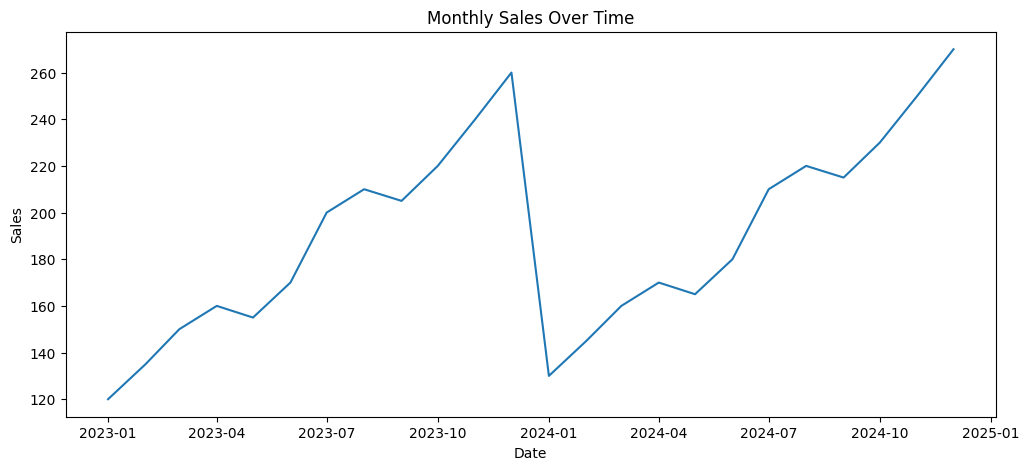

In [2]:

plt.figure(figsize=(12,5))
plt.plot(df['Sales'])
plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## 3. Rolling Mean (Trend Detection)

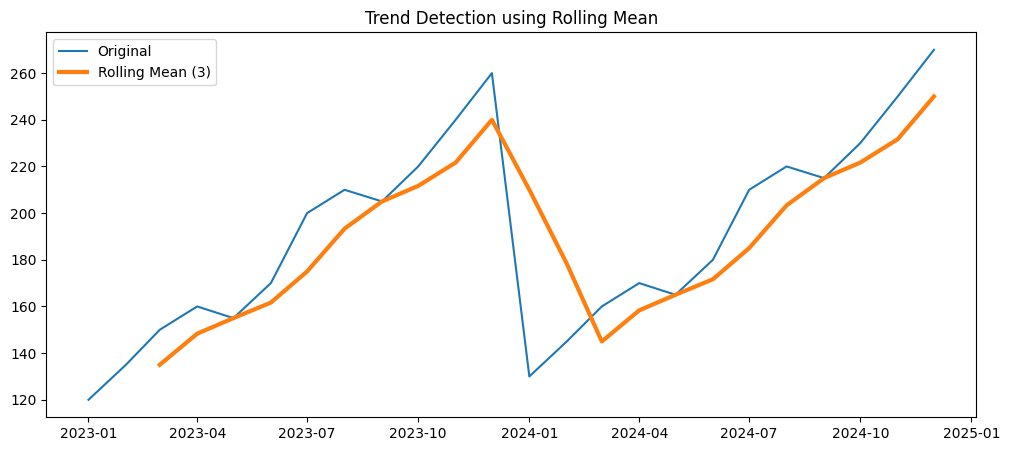

In [3]:
df['Rolling_Mean'] = df['Sales'].rolling(window=3).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Sales'], label="Original")
plt.plot(df['Rolling_Mean'], label="Rolling Mean (3)", linewidth=3)
plt.legend()
plt.title("Trend Detection using Rolling Mean")
plt.show()

## 4. Monthly Seasonality Check

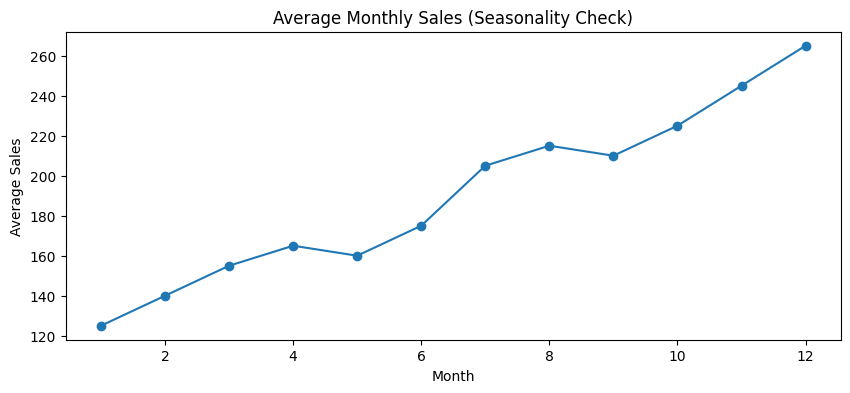

In [4]:
df['Month'] = df.index.month

monthly_avg = df.groupby('Month')['Sales'].mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_avg, marker='o')
plt.title("Average Monthly Sales (Seasonality Check)")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

## 5. Noise / Residual Component

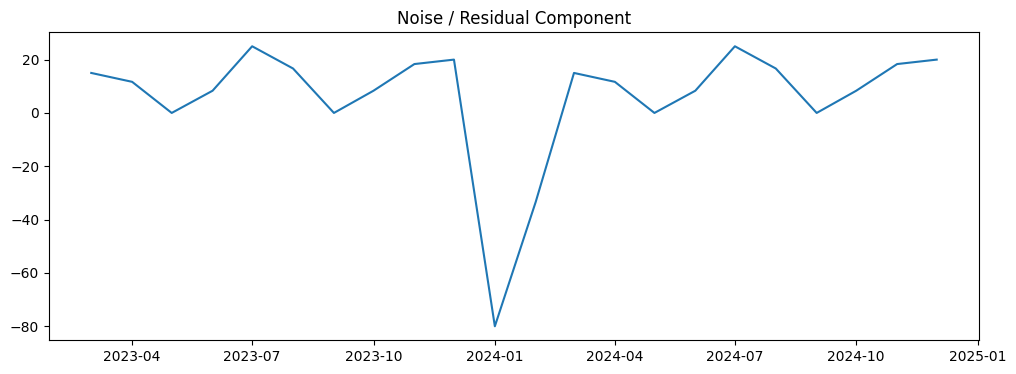

In [5]:
df['Residual'] = df['Sales'] - df['Rolling_Mean']

plt.figure(figsize=(12,4))
plt.plot(df['Residual'])
plt.title("Noise / Residual Component")
plt.show()

## 6. Time Series Decomposition (Core EDA Step)

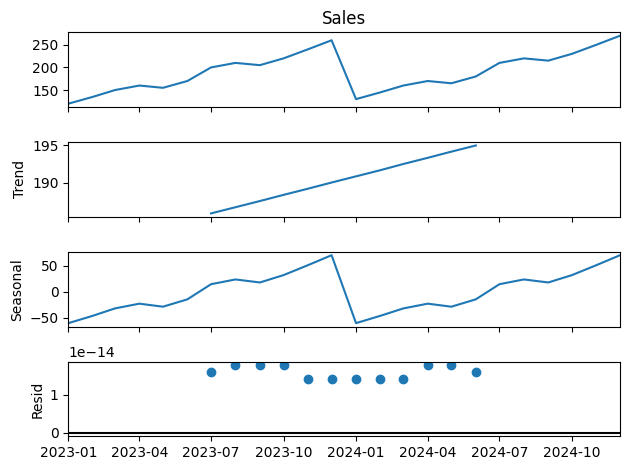

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Sales'], model='additive', period=12)

decomposition.plot()
plt.show()

## 7. ACF (Autocorrelation Check – VERY IMPORTANT for next chapter)

<Figure size 1000x400 with 0 Axes>

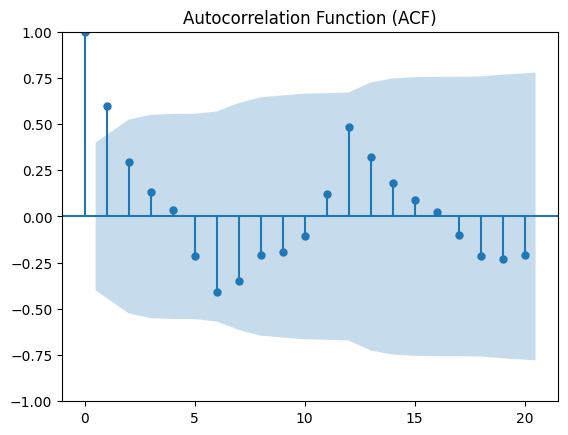

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(df['Sales'], lags=20)
plt.title("Autocorrelation Function (ACF)")
plt.show()

## 8. Differencing (Stationarity Preparation)

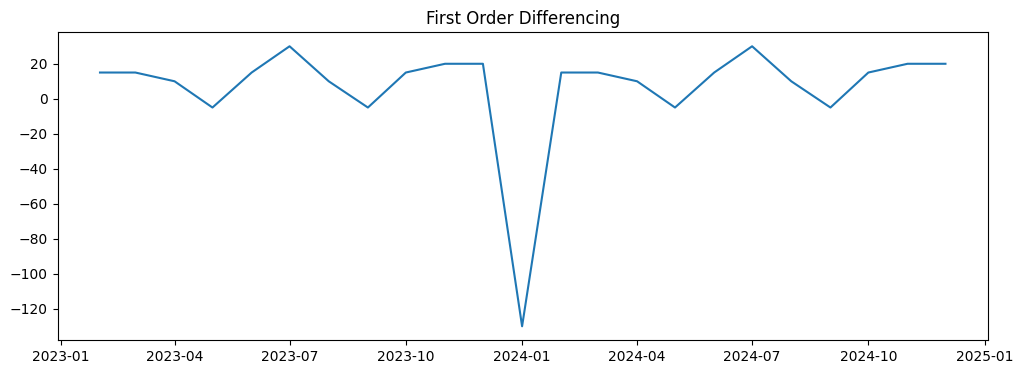

In [8]:
df['Diff'] = df['Sales'].diff()

plt.figure(figsize=(12,4))
plt.plot(df['Diff'])
plt.title("First Order Differencing")
plt.show()

## 9. Summary Statistics for Business Insight

In [9]:
df['Sales'].describe()

count     24.000000
mean     190.416667
std       42.857617
min      120.000000
25%      158.750000
50%      190.000000
75%      220.000000
max      270.000000
Name: Sales, dtype: float64

### Practice

In [4]:
# Import required libraries
# pandas → data handling
# numpy → numerical operations
# matplotlib → visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Create a date range for 24 months (2 years)
date = pd.date_range(start='2023-01-01', periods=24, freq='M')

# Simulated monthly sales data (contains trend + seasonality)
sales = [120,135,150,160,155,170,200,210,205,220,240,260,
         130,145,160,170,165,180,210,220,215,230,250,270]

# Create DataFrame and set Date as index (important for time series)
df = pd.DataFrame({'Date': date, 'Sales': sales})
df.set_index('Date', inplace=True)

# Display first few rows
df.head()

C:\Users\oadsa\AppData\Local\Temp\ipykernel_26468\3216186170.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date = pd.date_range(start='2023-01-01', periods=24, freq='M')


,Sales
Date,
2023-01-31,120
2023-02-28,135
2023-03-31,150
2023-04-30,160
2023-05-31,155


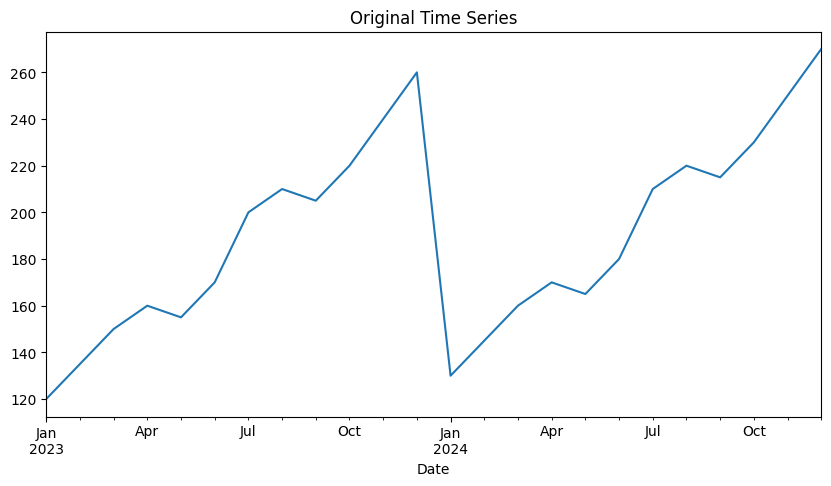

In [6]:
# Plot the original time series
# This helps us visually inspect trend and fluctuations

df['Sales'].plot(title="Original Time Series", figsize=(10,5))
plt.show()

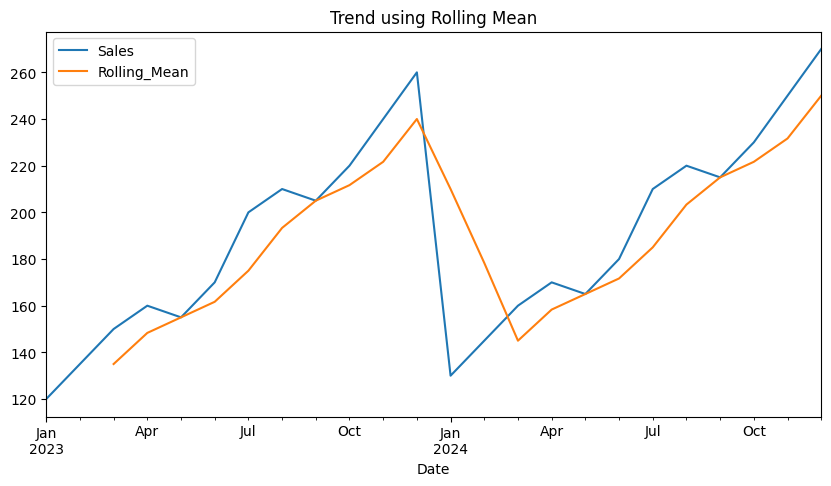

In [7]:
# Calculate rolling mean (window = 3 months)
# This smooths short-term fluctuations and highlights trend

df['Rolling_Mean'] = df['Sales'].rolling(window=3).mean()

# Plot original vs smoothed data
df[['Sales','Rolling_Mean']].plot(title="Trend using Rolling Mean", figsize=(10,5))
plt.show()

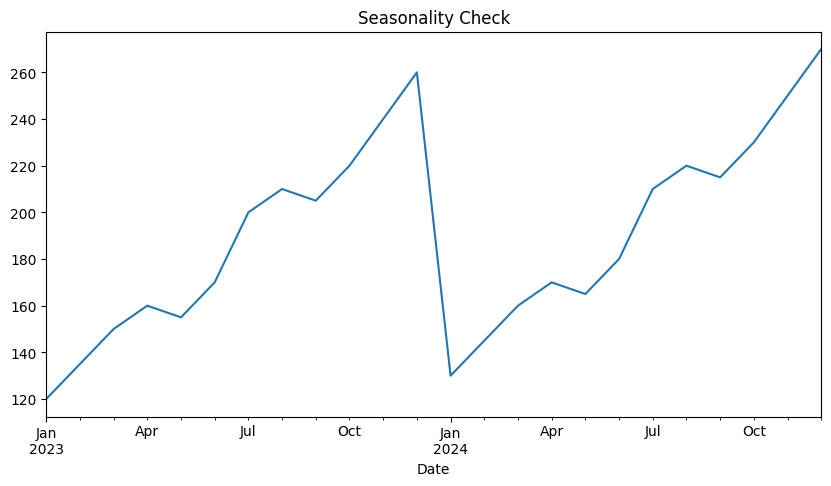

In [8]:
# Re-plot the series to visually inspect repeating patterns
# Look for similar shapes repeating over time → indicates seasonality

df['Sales'].plot(title="Seasonality Check", figsize=(10,5))
plt.show()

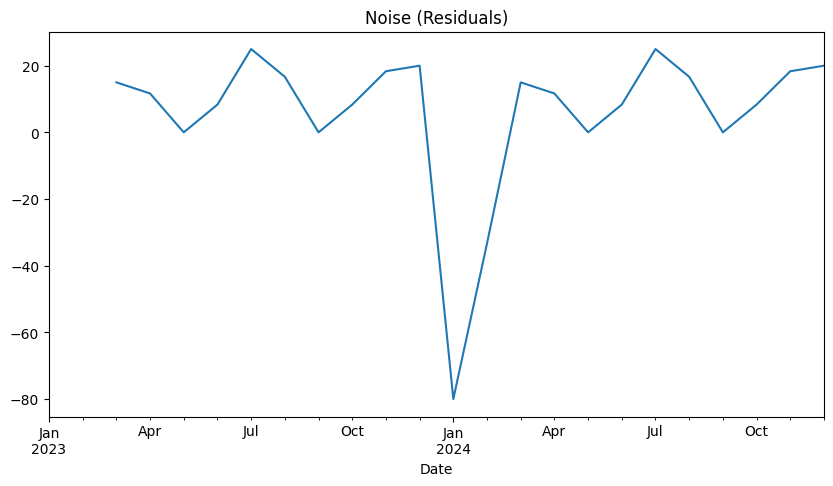

In [9]:
# Calculate noise (residual fluctuations)
# Noise = actual values - smoothed values

df['Noise'] = df['Sales'] - df['Rolling_Mean']

# Plot noise to see randomness in the data
df['Noise'].plot(title="Noise (Residuals)", figsize=(10,5))
plt.show()

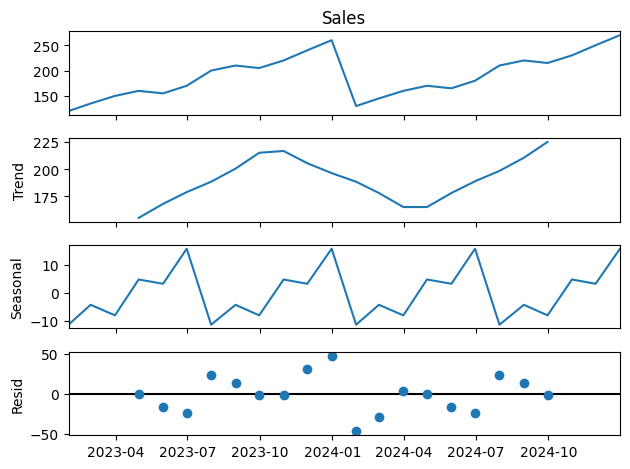

In [10]:
# Decompose time series into components
# Trend → long-term direction
# Seasonal → repeating patterns
# Residual → noise

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Sales'], model='additive', period=6)

# Plot all components
decomposition.plot()
plt.show()

## Final Summary

From this analysis, we observe:

- A clear upward trend → indicating sustained business growth  
- Repeating patterns → confirming the presence of seasonality  
- Moderate randomness → present but not dominating the overall structure  

### Key Insight:
Understanding the structure of the data is essential before applying forecasting models.

Based on these observations:
- ARIMA is suitable for non-seasonal data  
- SARIMA is more appropriate when seasonality is present  

This analysis ensures that model selection is driven by data characteristics, not assumptions.